## Importación de librerías

In [4]:
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, \
    classification_report

%matplotlib inline

sns.set_theme()


## Carga del dataset

In [5]:
df_train = pd.read_csv('../../../dataset/oulad/generated/dataset_train_2013_full_60d.csv')
df_test = pd.read_csv('../../../dataset/oulad/generated/dataset_test_2014_full_60d.csv')

columnas_sensibles = ['gender', 'region', 'imd_band', 'age_band', 'disability']
df_train = df_train.drop(columns=columnas_sensibles, errors='ignore')
df_test = df_test.drop(columns=columnas_sensibles, errors='ignore')

df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

X_train = df_train.drop(columns=['target_burnout'], errors='ignore')
y_train = df_train['target_burnout']
X_test = df_test.drop(columns=['target_burnout'], errors='ignore')
y_test = df_test['target_burnout']

print("--- DISTRIBUCIÓN ORIGINAL (60 DÍAS | SIN DATOS SENSIBLES) ---")
print(f"Train 2013 - Total: {len(X_train)} | Riesgo (1): {y_train.sum()} | Éxito (0): {len(y_train) - y_train.sum()}")
print(f"Test 2014  - Total: {len(X_test)} | Riesgo (1): {y_test.sum()} | Éxito (0): {len(y_test) - y_test.sum()}")

--- DISTRIBUCIÓN ORIGINAL (60 DÍAS | SIN DATOS SENSIBLES) ---
Train 2013 - Total: 11142 | Riesgo (1): 3348 | Éxito (0): 7794
Test 2014  - Total: 10801 | Riesgo (1): 3693 | Éxito (0): 7108


## Entrenamieto

In [7]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN
from sklearn.svm import SVC

# 1. Definición de columnas (versión 60 días)
cat_cols = ['highest_education']
num_cols = [
    'num_of_prev_attempts', 'studied_credits',
    'total_clicks_60d', 'media_clicks_semanales', 'total_dias_activos',
    'semanas_con_actividad', 'semanas_actividad_plena', 'max_clicks_1_dia',
    'semanas_sin_clicks', 'dias_sin_clicks_60d',
    'entregas_realizadas_60d', 'nota_media_60d', 'retraso_medio_dias', 'total_entregas_tardias',
    'clicks_semana_0', 'clicks_semana_1', 'clicks_semana_2', 'clicks_semana_3',
    'clicks_semana_4', 'clicks_semana_5', 'clicks_semana_6', 'clicks_semana_7', 'clicks_semana_8'
]

# 2. Configuración de transformadores
num_transformer = SklearnPipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

cat_transformer = SklearnPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

# 3. Ensamblado del Pipeline con ADASYN y SVM
svm_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', ADASYN(random_state=42, n_neighbors=5)),
    ('classifier', SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ))
])

# 4. Entrenamiento y Predicción
svm_pipeline.fit(X_train, y_train)
y_pred = svm_pipeline.predict(X_test)

print("Entrenamiento de SVM + ADASYN finalizado con éxito.")

Entrenamiento de SVM + ADASYN finalizado con éxito.


## Evaluación y Gráficas de Rendimiento

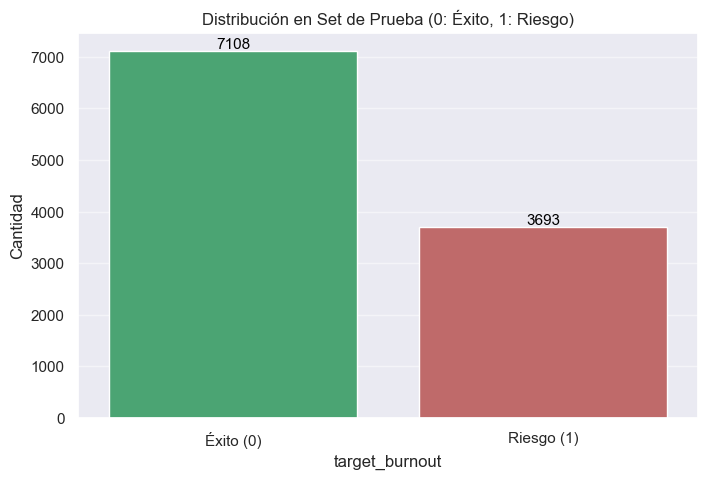

--- REPORTE DE CLASIFICACIÓN DETALLADO (Umbral: 0.44) ---
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      7108
           1       0.61      0.82      0.70      3693

    accuracy                           0.76     10801
   macro avg       0.75      0.78      0.75     10801
weighted avg       0.79      0.76      0.77     10801



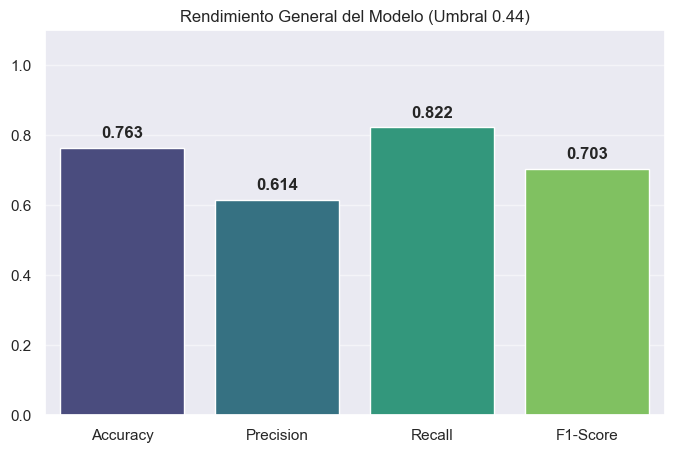

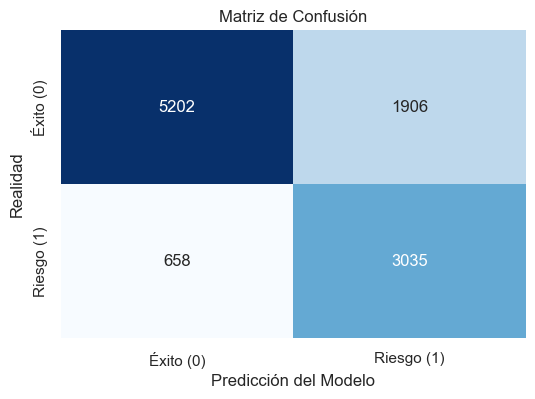

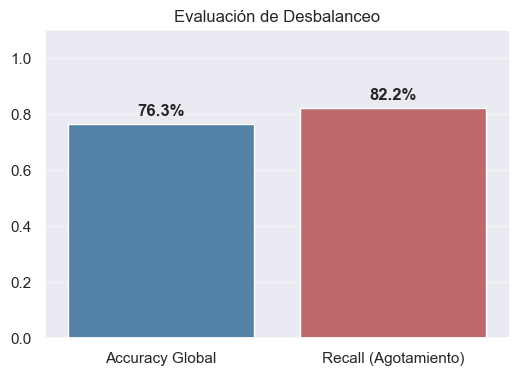

In [8]:
y_probs = svm_pipeline.predict_proba(X_test)[:, 1]

# UMBRAL PERMISIVO
umbral_permisivo = 0.44
y_pred = (y_probs >= umbral_permisivo).astype(int)

fig1 = plt.figure(figsize=(8, 5))

ax1 = sns.countplot(x=y_test, hue=y_test, palette=['#3CB371', '#CD5C5C'], legend=False)
plt.title('Distribución en Set de Prueba (0: Éxito, 1: Riesgo)')
plt.xticks(ticks=[0, 1], labels=['Éxito (0)', 'Riesgo (1)'])
plt.ylabel('Cantidad')

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"--- REPORTE DE CLASIFICACIÓN DETALLADO (Umbral: {umbral_permisivo}) ---")
print(classification_report(y_test, y_pred, zero_division=0))

fig2 = plt.figure(figsize=(8, 5))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]
ax2 = sns.barplot(x=metrics_names, y=metrics_values, hue=metrics_names, palette='viridis', legend=False)
plt.title(f'Rendimiento General del Modelo (Umbral {umbral_permisivo})')
plt.ylim(0, 1.1)

for i, v in enumerate(metrics_values):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')
plt.show()

cm = confusion_matrix(y_test, y_pred)

fig3 = plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Éxito (0)', 'Riesgo (1)'],
            yticklabels=['Éxito (0)', 'Riesgo (1)'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()

report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
burnout_recall = report_dict['1']['recall']

fig4 = plt.figure(figsize=(6, 4))

metric_names_comp = ['Accuracy Global', 'Recall (Agotamiento)']
metric_values_comp = [acc, burnout_recall]
ax4 = sns.barplot(x=metric_names_comp, y=metric_values_comp, hue=metric_names_comp, palette=['#4682B4', '#CD5C5C'],
                  legend=False)
plt.title('Evaluación de Desbalanceo')
plt.ylim(0, 1.1)

for i, v in enumerate(metric_values_comp):
    ax4.text(i, v + 0.02, f"{v * 100:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.show()

## Grid search

In [9]:
param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf'],
    'classifier__gamma': ['scale', 'auto']
    # class_weight eliminado del grid
}

print("Iniciando Grid Search...")
print("Entrenando múltiples combinaciones mediante validación cruzada (CV=3)...")

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=param_grid_svm,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n" + "=" * 50)
print("¡BÚSQUEDA FINALIZADA!")
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f" - {param.replace('classifier__', '')}: {value}")
print("=" * 50)

mejor_modelo = grid_search.best_estimator_

umbral_prueba = 0.15
y_probs_grid = mejor_modelo.predict_proba(X_test)[:, 1]
y_pred_grid = (y_probs_grid >= umbral_prueba).astype(int)

print(f"\n--- REPORTE DEL MEJOR MODELO (Umbral: {umbral_prueba}) ---")
print(classification_report(y_test, y_pred_grid, zero_division=0))

print("=" * 65)
print(" BUSCANDO EL UMBRAL ÓPTIMO PARA EL MODELO GANADOR")
print("=" * 65)
print(f"{'Umbral':<8} | {'Accuracy Global':<18} | {'Recall (Riesgo)':<18} | {'Precisión (Riesgo)':<18}")
print("-" * 65)

umbrales_prueba = np.arange(0.30, 0.85, 0.05)

for u in umbrales_prueba:
    y_pred_temp = (y_probs_grid >= u).astype(int)

    acc = accuracy_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp, zero_division=0)
    prec = precision_score(y_test, y_pred_temp, zero_division=0)

    print(f"{u:.2f}     | {acc * 100:>5.1f}%             | {rec * 100:>5.1f}%             | {prec * 100:>5.1f}%")

Iniciando Grid Search...
Entrenando múltiples combinaciones mediante validación cruzada (CV=3)...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

¡BÚSQUEDA FINALIZADA!
Mejores hiperparámetros encontrados:
 - C: 0.1
 - gamma: auto
 - kernel: rbf

--- REPORTE DEL MEJOR MODELO (Umbral: 0.15) ---
              precision    recall  f1-score   support

           0       0.90      0.00      0.01      7108
           1       0.34      1.00      0.51      3693

    accuracy                           0.34     10801
   macro avg       0.62      0.50      0.26     10801
weighted avg       0.71      0.34      0.18     10801

 BUSCANDO EL UMBRAL ÓPTIMO PARA EL MODELO GANADOR
Umbral   | Accuracy Global    | Recall (Riesgo)    | Precisión (Riesgo)
-----------------------------------------------------------------
0.30     |  60.0%             |  92.9%             |  45.8%
0.35     |  65.8%             |  89.8%             |  50.0%
0.40     |  70.3%             |  86.7%             |  54.

## SHAP

In [10]:
import shap

print("\n" + "=" * 65)
print(" GENERANDO EXPLICACIONES DEL MODELO GANADOR CON SHAP")
print("=" * 65)

modelo_puro = mejor_modelo.named_steps['classifier']
preprocesador_ganador = mejor_modelo.named_steps['preprocessor']

X_test_transformado = preprocesador_ganador.transform(X_test)

nombres_columnas = preprocesador_ganador.get_feature_names_out()

X_test_shap = pd.DataFrame(X_test_transformado, columns=nombres_columnas)

X_test_shap.columns = X_test_shap.columns.str.replace(r"[\[\]<]", "_", regex=True)

explainer = shap.TreeExplainer(modelo_puro)
shap_values = explainer.shap_values(X_test_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_shap, plot_type="bar",
                  max_display=X_test_shap.shape[1],
                  show=False)
plt.title("Importancia Global de Características (SHAP)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_shap,
                  max_display=X_test_shap.shape[1],
                  show=False)
plt.title("Impacto de las Variables en el Riesgo de Abandono (SHAP)")
plt.tight_layout()
plt.show()

print("\nGenerando explicación individual (Waterfall Plot)...")
explicacion_completa = explainer(X_test_shap)
indice_estudiante = 0
shap.plots.waterfall(explicacion_completa[indice_estudiante], max_display=10, show=False)
plt.title(f"Desglose Predictivo - Estudiante ID Test: {indice_estudiante}")
plt.tight_layout()
plt.show()

C:\Users\joseb\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



 GENERANDO EXPLICACIONES DEL MODELO GANADOR CON SHAP


InvalidModelError: Model type not yet supported by TreeExplainer: <class 'sklearn.svm._classes.SVC'>